# Inozemtsev Chain: From Long-Range Integrability Toward Chaos

This notebook starts from a finite Inozemtsev-style long-range Heisenberg chain and then gradually removes interaction shells.

The goal is to track how the spectral, entanglement, ETH, and quench diagnostics evolve as the model is truncated away from the full long-range Hamiltonian.

The analysis mirrors the earlier XXZ notebooks:
- entanglement entropy vs energy
- entanglement spectrum and entanglement energies
- ETH fluctuations
- level-spacing statistics and mean r
- standardized entropy curves and gradients
- quench entanglement growth

In [11]:
from inozemtsev_chaos_tools import InozemtsevChain

import matplotlib.pyplot as plt
import numpy as np

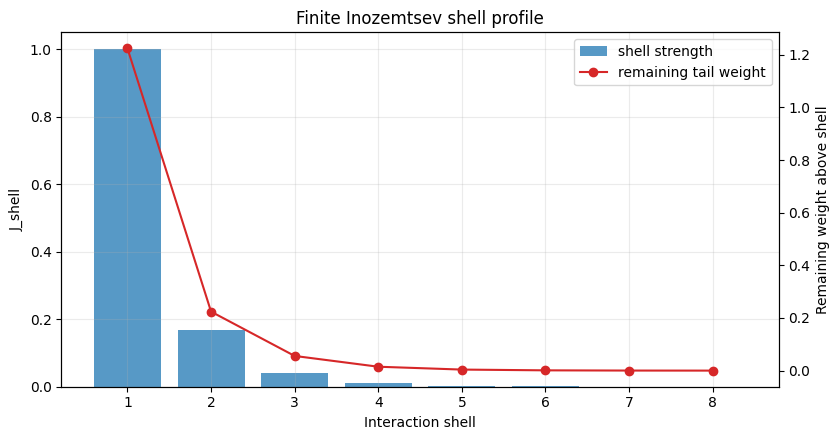

In [12]:
# Build the full finite-chain model and inspect the shell profile.
L = 16
chain = InozemtsevChain(L=L, Nup=L // 2, periodic=True, alpha=0.65, normalize_shells=True)
full_shell = chain.max_unique_shell
max_shell_values = np.arange(full_shell, 0, -1)

shells = np.arange(1, full_shell + 1)
weights = np.array([chain.shell_strength(shell) for shell in shells], dtype=float)
remaining_weight = np.array([weights[:shell].sum() for shell in range(len(weights), 0, -1)], dtype=float)

fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax1.bar(shells, weights, color='tab:blue', alpha=0.75, label='shell strength')
ax1.set_xlabel('Interaction shell')
ax1.set_ylabel('J_shell')
ax1.set_title('Finite Inozemtsev shell profile')
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(shells, np.cumsum(weights[::-1])[::-1], color='tab:red', marker='o', label='remaining tail weight')
ax2.set_ylabel('Remaining weight above shell')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

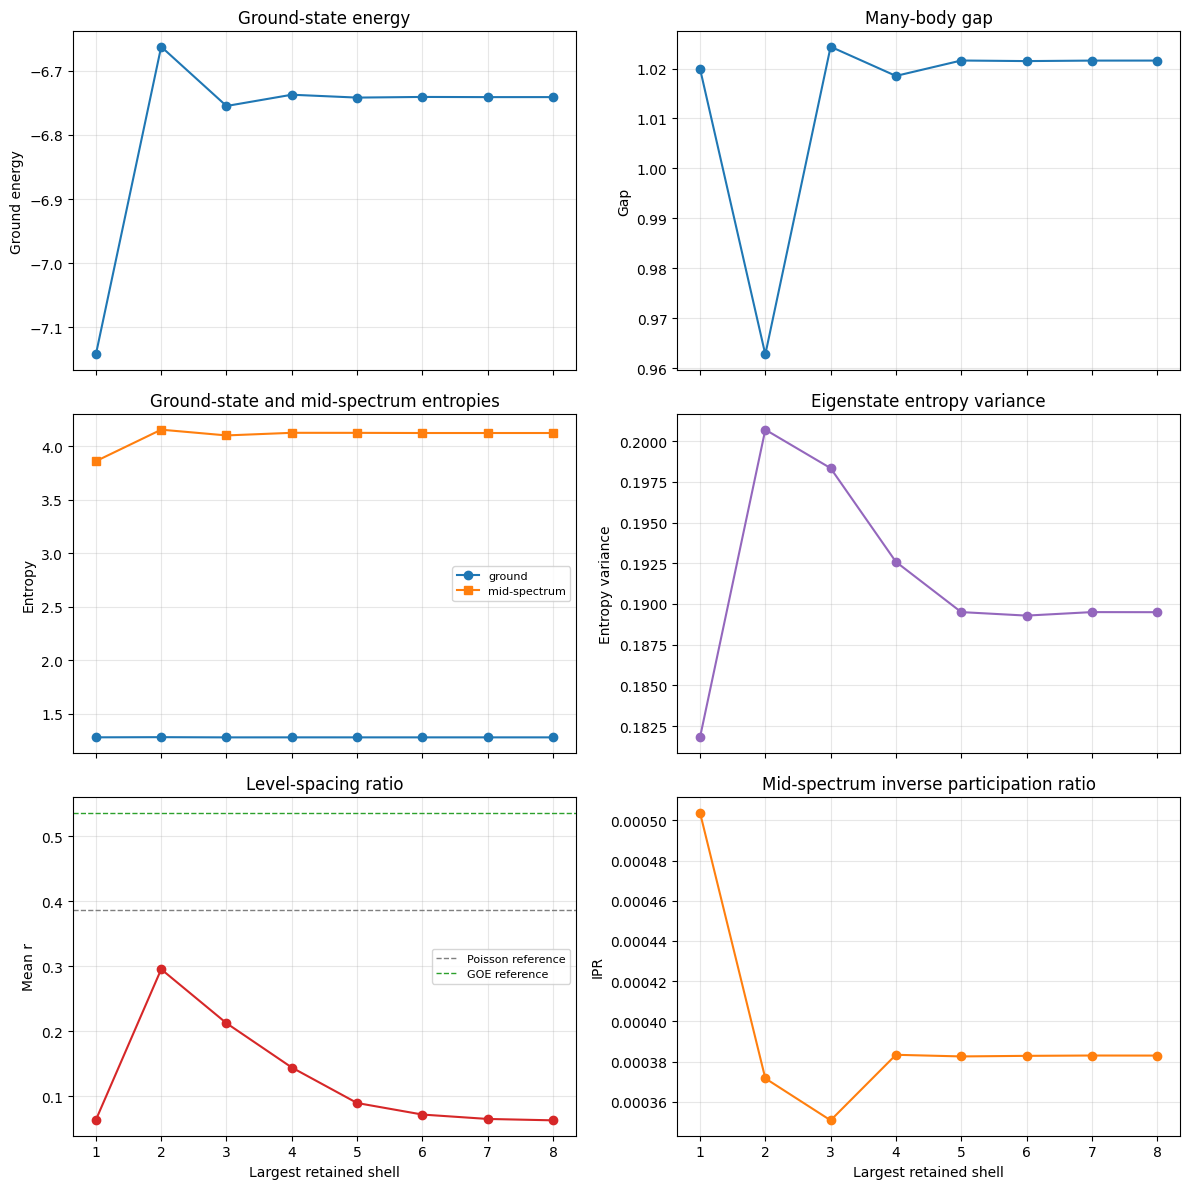

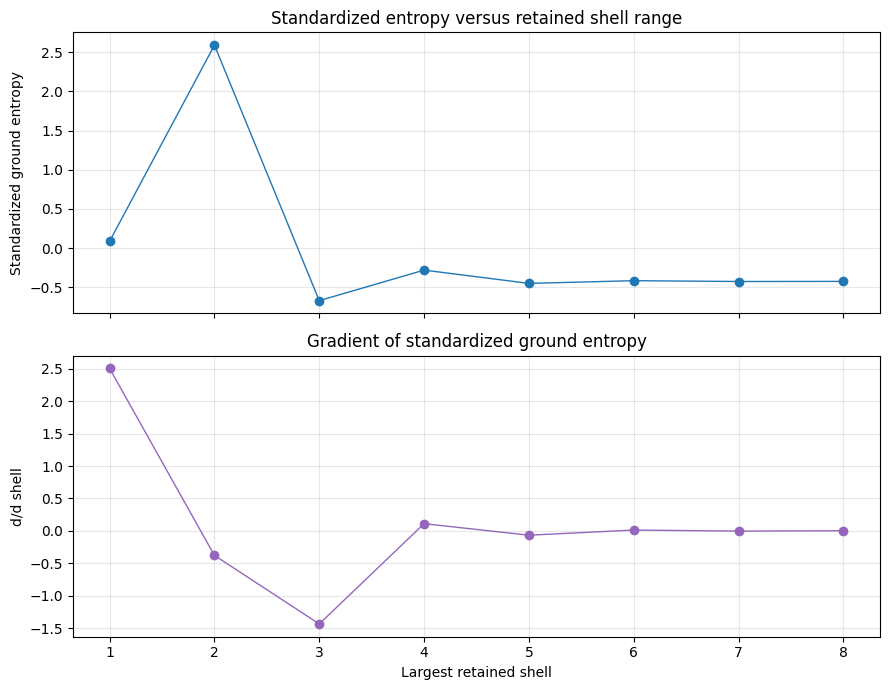

In [13]:
# Sweep from the full long-range model down to the nearest-neighbour truncation.
diag = chain.chaos_diagnostics(max_shell_values, block_size=L // 2, momentum_sector=0)

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)

axes[0, 0].plot(diag['max_shell_values'], diag['ground_energy'], marker='o')
axes[0, 0].set_ylabel('Ground energy')
axes[0, 0].set_title('Ground-state energy')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(diag['max_shell_values'], diag['gap'], marker='o')
axes[0, 1].set_ylabel('Gap')
axes[0, 1].set_title('Many-body gap')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(diag['max_shell_values'], diag['ground_entropy'], marker='o')
axes[1, 0].plot(diag['max_shell_values'], diag['mid_entropy'], marker='s')
axes[1, 0].set_ylabel('Entropy')
axes[1, 0].set_title('Ground-state and mid-spectrum entropies')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(['ground', 'mid-spectrum'], fontsize=8)

axes[1, 1].plot(diag['max_shell_values'], diag['entropy_variance'], marker='o', color='tab:purple')
axes[1, 1].set_ylabel('Entropy variance')
axes[1, 1].set_title('Eigenstate entropy variance')
axes[1, 1].grid(True, alpha=0.3)

axes[2, 0].plot(diag['max_shell_values'], diag['r_statistic'], marker='o', color='tab:red')
axes[2, 0].axhline(0.386, color='tab:gray', linestyle='--', linewidth=1, label='Poisson reference')
axes[2, 0].axhline(0.536, color='tab:green', linestyle='--', linewidth=1, label='GOE reference')
axes[2, 0].set_xlabel('Largest retained shell')
axes[2, 0].set_ylabel('Mean r')
axes[2, 0].set_title('Level-spacing ratio')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend(fontsize=8)

axes[2, 1].plot(diag['max_shell_values'], diag['ipr'], marker='o', color='tab:orange')
axes[2, 1].set_xlabel('Largest retained shell')
axes[2, 1].set_ylabel('IPR')
axes[2, 1].set_title('Mid-spectrum inverse participation ratio')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ground_entropy = np.asarray(diag['ground_entropy'], dtype=float)
entropy_mean = ground_entropy.mean()
entropy_std = ground_entropy.std()
if entropy_std > 0:
    standardized_entropy = (ground_entropy - entropy_mean) / entropy_std
else:
    standardized_entropy = ground_entropy - entropy_mean

entropy_gradient = np.gradient(standardized_entropy, diag['max_shell_values'])

fig, (ax_entropy, ax_grad) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax_entropy.plot(diag['max_shell_values'], standardized_entropy, marker='o', linewidth=1)
ax_entropy.set_ylabel('Standardized ground entropy')
ax_entropy.set_title('Standardized entropy versus retained shell range')
ax_entropy.grid(True, alpha=0.3)

ax_grad.plot(diag['max_shell_values'], entropy_gradient, marker='o', linewidth=1, color='tab:purple')
ax_grad.set_xlabel('Largest retained shell')
ax_grad.set_ylabel('d/d shell')
ax_grad.set_title('Gradient of standardized ground entropy')
ax_grad.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

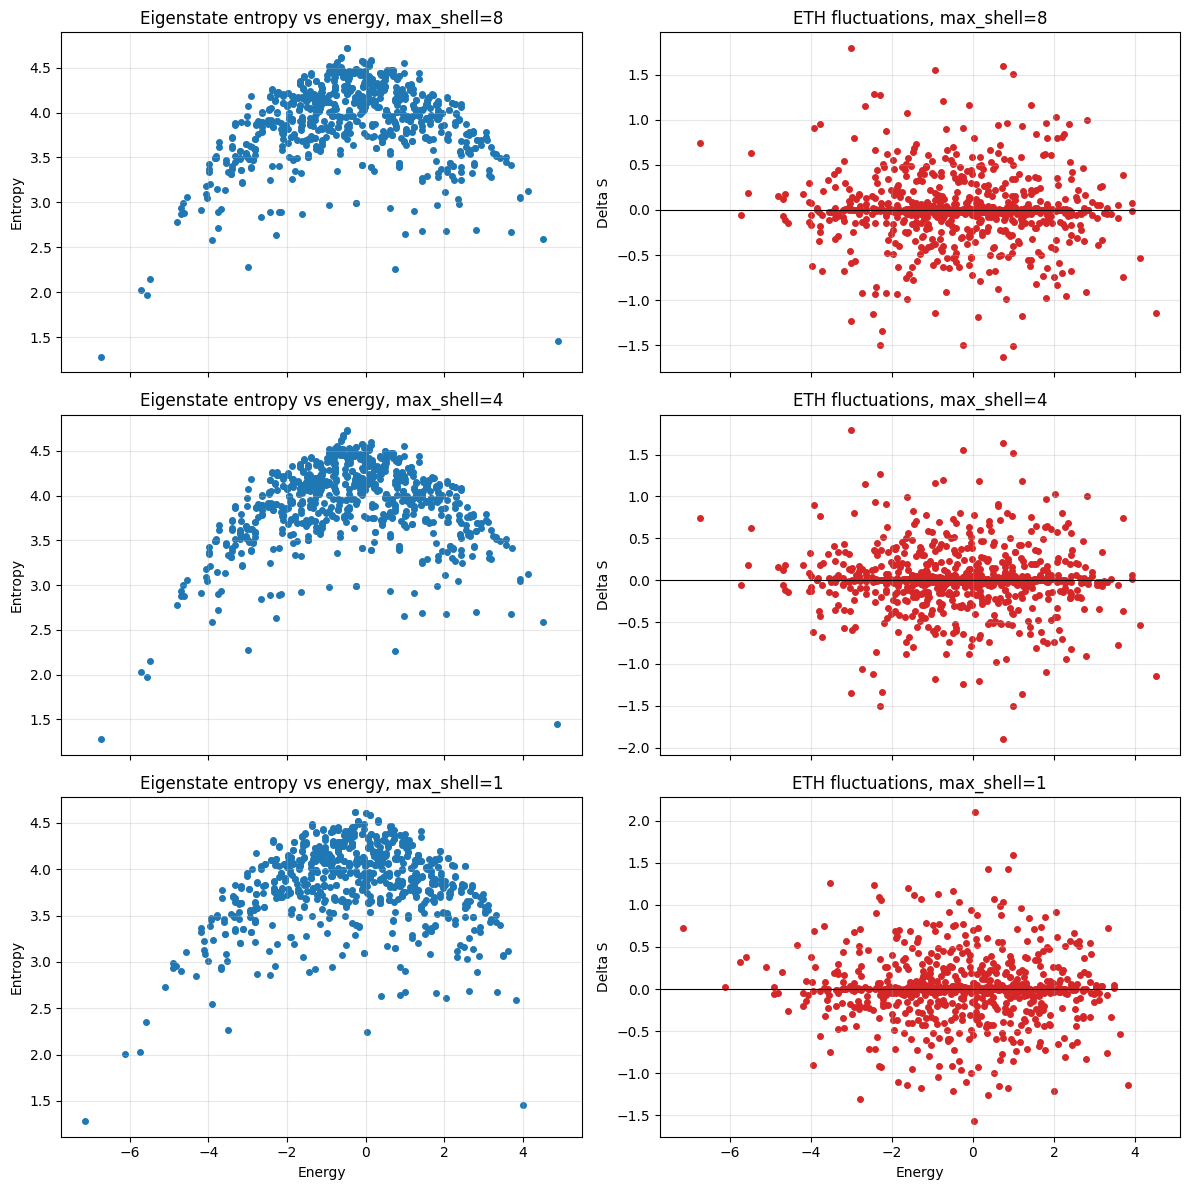

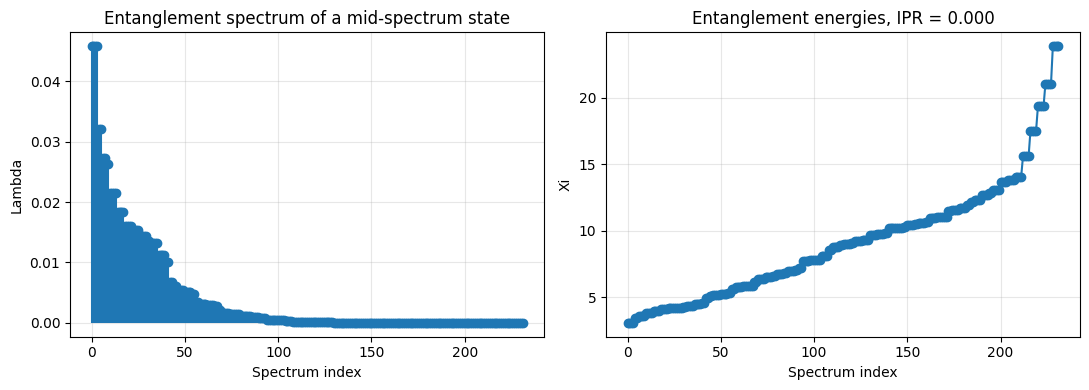

In [14]:
# Compare eigenstate entanglement, entanglement spectrum, and ETH fluctuations
# for a few representative truncation levels.
representative_shells = [full_shell, max(1, full_shell // 2), 1]

fig, axes = plt.subplots(len(representative_shells), 2, figsize=(12, 4 * len(representative_shells)), sharex='col')
if len(representative_shells) == 1:
    axes = np.asarray([axes])

for row, max_shell in enumerate(representative_shells):
    E, entropies = chain.eigenstate_entropies(block_size=L // 2, max_shell=max_shell, momentum_sector=0)
    fluc_E, fluc = chain.eth_fluctuations(block_size=L // 2, max_shell=max_shell, momentum_sector=0)

    axes[row, 0].scatter(E, entropies, s=16)
    axes[row, 0].set_ylabel('Entropy')
    axes[row, 0].set_title(f'Eigenstate entropy vs energy, max_shell={max_shell}')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].scatter(fluc_E, fluc, s=16, color='tab:red')
    axes[row, 1].axhline(0.0, color='black', linewidth=0.8)
    axes[row, 1].set_ylabel('Delta S')
    axes[row, 1].set_title(f'ETH fluctuations, max_shell={max_shell}')
    axes[row, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Energy')
axes[-1, 1].set_xlabel('Energy')

plt.tight_layout()
plt.show()

E_full, V_full = chain.eigensystem(max_shell=full_shell, momentum_sector=0)
mid = len(E_full) // 2
lambdas = chain.entanglement_spectrum(V_full[:, mid], block_size=L // 2)
xi = chain.entanglement_energies(V_full[:, mid], block_size=L // 2)
ipr_mid = chain.inverse_participation_ratio(V_full[:, mid])

fig, (ax_lambda, ax_xi) = plt.subplots(1, 2, figsize=(11, 4))
ax_lambda.stem(np.arange(len(lambdas)), lambdas, basefmt=' ')
ax_lambda.set_xlabel('Spectrum index')
ax_lambda.set_ylabel('Lambda')
ax_lambda.set_title('Entanglement spectrum of a mid-spectrum state')
ax_lambda.grid(True, alpha=0.3)

ax_xi.plot(xi, marker='o')
ax_xi.set_xlabel('Spectrum index')
ax_xi.set_ylabel('Xi')
ax_xi.set_title(f'Entanglement energies, IPR = {ipr_mid:.3f}')
ax_xi.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

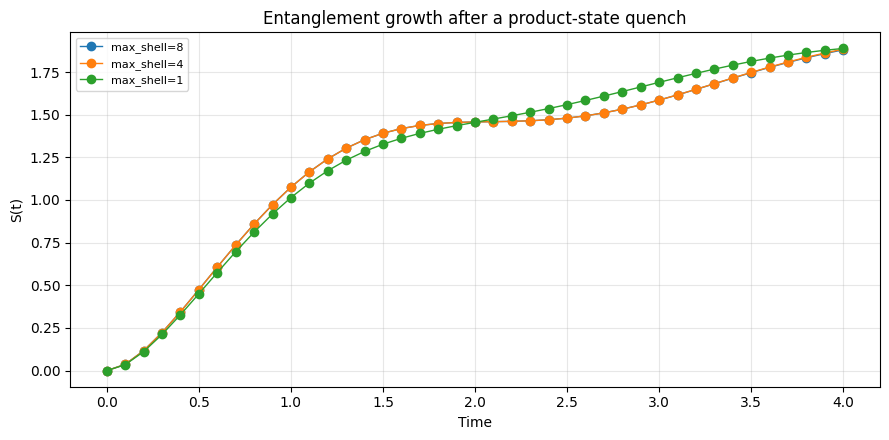

Full model mean r in k=0 sector: 0.0633


In [15]:
# Quench entanglement growth for the full model and a strongly truncated model.
psi0 = np.zeros(chain.hilbert_dimension(), dtype=complex)
psi0[0] = 1.0
times = np.linspace(0.0, 4.0, 41)

cutoff_choices = [full_shell, max(1, full_shell // 2), 1]
fig, ax = plt.subplots(figsize=(9, 4.5))

for max_shell in cutoff_choices:
    t, growth = chain.quench_entanglement_growth(psi0, times, block_size=L // 2, max_shell=max_shell)
    ax.plot(t, growth, marker='o', linewidth=1, label=f'max_shell={max_shell}')

ax.set_xlabel('Time')
ax.set_ylabel('S(t)')
ax.set_title('Entanglement growth after a product-state quench')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Full model mean r in k=0 sector: {chain.mean_r_statistic(max_shell=full_shell, momentum_sector=0):.4f}')